In [ ]:
# ============================================================
# 04_stacking_fusion.ipynb
# Multimodal Fusion via Stacking (Audio Expert + Text Expert)
# Proyecto MIR — Fusión Audio + Texto
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("✔ Imports básicos cargados.")


✔ Imports básicos cargados.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import sys

def get_project_paths():
    """
    Busca la carpeta 'Proyecto Final MIR' tanto en local como en Drive.
    Configura rutas clave del proyecto.
    """
    cwd = Path.cwd()

    # 1) Local / entorno tipo VSCode
    for parent in [cwd] + list(cwd.parents):
        if (parent / "Proyecto Final MIR").exists():
            root = parent / "Proyecto Final MIR"
            break
    else:
        # 2) Colab + Drive
        drive_path = Path("/content/drive/MyDrive")
        if (drive_path / "Proyecto Final MIR").exists():
            root = drive_path / "Proyecto Final MIR"
        else:
            raise FileNotFoundError("❌ No se encontró la carpeta 'Proyecto Final MIR'.")

    paths = {
        "ROOT": root,
        "SRC": root / "src",
        "MODELS": root / "src" / "Models",
        "SAVED": root / "src" / "saved_models",
        "REPORTS": root / "reports",
        "AUDIO_PRED": root / "reports" / "audio_expert",
        "TEXT_PRED": root / "reports" / "text_expert",
    }
    return paths

paths = get_project_paths()

# Cambiar el CWD al root del proyecto
import os
os.chdir(paths["ROOT"])
print("✔ CWD configurado a:", Path.cwd())

# Agregar rutas al sys.path para futuros imports si los necesitaras
sys.path.append(str(paths["SRC"]))
sys.path.append(str(paths["MODELS"]))

print("✔ Rutas añadidas al sys.path")
print("📁 REPORTS:", paths["REPORTS"])
print("📁 AUDIO_PRED:", paths["AUDIO_PRED"])
print("📁 TEXT_PRED:", paths["TEXT_PRED"])


Mounted at /content/drive
✔ CWD configurado a: /content/drive/MyDrive/Proyecto Final MIR
✔ Rutas añadidas al sys.path
📁 REPORTS: /content/drive/MyDrive/Proyecto Final MIR/reports
📁 AUDIO_PRED: /content/drive/MyDrive/Proyecto Final MIR/reports/audio_expert
📁 TEXT_PRED: /content/drive/MyDrive/Proyecto Final MIR/reports/text_expert


In [ ]:
print("📂 Contenido de audio_expert:")
for f in sorted(paths["AUDIO_PRED"].glob("predicciones_audio_*.csv")):
    print("   -", f.name)

print("\n📂 Contenido de text_expert:")
for f in sorted(paths["TEXT_PRED"].glob("predicciones_text_*.csv")):
    print("   -", f.name)


📂 Contenido de audio_expert:
   - predicciones_audio_TEST.csv
   - predicciones_audio_TEST_baseline.csv
   - predicciones_audio_TRAIN.csv
   - predicciones_audio_TRAIN_baseline.csv
   - predicciones_audio_VAL.csv
   - predicciones_audio_VAL_baseline.csv

📂 Contenido de text_expert:
   - predicciones_text_TEST.csv
   - predicciones_text_TEST_baseline.csv
   - predicciones_text_TRAIN.csv
   - predicciones_text_TRAIN_baseline.csv
   - predicciones_text_VAL.csv
   - predicciones_text_VAL_baseline.csv


In [ ]:
def load_and_merge(split, paths):
    """
    Carga predicciones del experto de audio y texto para un split dado,
    las une por spotify_id y devuelve:
      X:   matriz de features de dimensión [N, 8] (4 audio + 4 texto)
      y:   etiquetas verdaderas como enteros
      ids: lista de spotify_id
    """

    audio_path = paths["AUDIO_PRED"] / f"predicciones_audio_{split}.csv"
    text_path  = paths["TEXT_PRED"]  / f"predicciones_text_{split}.csv"

    print(f"\n📌 Cargando {audio_path.name} y {text_path.name} ...")

    df_a = pd.read_csv(audio_path)
    df_t = pd.read_csv(text_path)

    # merge por spotify_id
    df = df_a.merge(df_t, on="spotify_id", suffixes=("_audio", "_text"))

    # Detectar columna de labels (por si alguna vez se duplicó)
    label_candidates = ["true_label", "true_label_audio", "true_label_text"]
    label_col = None
    for col in label_candidates:
        if col in df.columns:
            label_col = col
            break

    if label_col is None:
        raise KeyError("❌ No se encontró ninguna columna de labels en el CSV fusionado.")

    # Extraer columnas de probabilidades
    audio_cols = [c for c in df.columns if c.startswith("prob_audio_")]
    text_cols  = [c for c in df.columns if c.startswith("prob_text_")]

    X_audio = df[audio_cols].to_numpy(np.float32)
    X_text  = df[text_cols].to_numpy(np.float32)

    X = np.concatenate([X_audio, X_text], axis=1)
    y = df[label_col].astype(int).to_numpy()
    ids = df["spotify_id"].tolist()

    print(f"✔ {split}: X.shape={X.shape}, y.shape={y.shape}, label_col={label_col}")
    return X, y, ids


In [ ]:
X_train, y_train, ids_train = load_and_merge("TRAIN", paths)
X_val,   y_val,   ids_val   = load_and_merge("VAL",   paths)
X_test,  y_test,  ids_test  = load_and_merge("TEST",  paths)

print("\nResumen shapes:")
print("   Train:", X_train.shape, y_train.shape)
print("   Val:  ", X_val.shape,   y_val.shape)
print("   Test: ", X_test.shape,  y_test.shape)



📌 Cargando predicciones_audio_TRAIN.csv y predicciones_text_TRAIN.csv ...
✔ TRAIN: X.shape=(4518, 8), y.shape=(4518,), label_col=true_label_audio

📌 Cargando predicciones_audio_VAL.csv y predicciones_text_VAL.csv ...
✔ VAL: X.shape=(968, 8), y.shape=(968,), label_col=true_label_audio

📌 Cargando predicciones_audio_TEST.csv y predicciones_text_TEST.csv ...
✔ TEST: X.shape=(969, 8), y.shape=(969,), label_col=true_label_audio

Resumen shapes:
   Train: (4518, 8) (4518,)
   Val:   (968, 8) (968,)
   Test:  (969, 8) (969,)


In [ ]:
import collections

def print_class_distribution(y, name):
    counter = collections.Counter(y)
    print(f"\nDistribución de clases en {name}:")
    for k in sorted(counter.keys()):
        print(f"  Clase {k}: {counter[k]} muestras")

print_class_distribution(y_train, "TRAIN")
print_class_distribution(y_val,   "VAL")
print_class_distribution(y_test,  "TEST")



Distribución de clases en TRAIN:
  Clase 0: 1390 muestras
  Clase 1: 1393 muestras
  Clase 2: 1391 muestras
  Clase 3: 344 muestras

Distribución de clases en VAL:
  Clase 0: 298 muestras
  Clase 1: 299 muestras
  Clase 2: 298 muestras
  Clase 3: 73 muestras

Distribución de clases en TEST:
  Clase 0: 298 muestras
  Clase 1: 299 muestras
  Clase 2: 298 muestras
  Clase 3: 74 muestras


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 128

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=batch_size, shuffle=True
)

val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
    batch_size=batch_size, shuffle=False
)

test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=batch_size, shuffle=False
)

print("✔ DataLoaders creados.")


✔ DataLoaders creados.


In [ ]:
class Lineal(nn.Module):
    """
    Meta-learner lineal: recibe 8 features (4 audio + 4 texto)
    y produce logits para 4 clases.
    """
    def __init__(self, in_features=8, num_classes=4):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.fc(x)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando dispositivo:", device)

num_classes = len(np.unique(y_train))
model = Lineal(in_features=8, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 60
best_val_acc = 0.0
best_state_dict = None
patience = 8
epochs_no_improve = 0

def run_epoch(model, loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.set_grad_enabled(train_mode):
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)

            logits = model(Xb)
            loss = criterion(logits, yb)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(1)
            total_correct += (preds == yb).sum().item()
            total_loss += loss.item() * yb.size(0)
            total_samples += yb.size(0)

    return total_loss / total_samples, total_correct / total_samples

print("\n🚀 Entrenando FusionNet (lineal)...")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, train_mode=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   train_mode=False)

    print(f"Ep {epoch:03d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc + 1e-4:
        best_val_acc = val_acc
        best_state_dict = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"⛔ Early stopping activado (paciencia={patience}).")
        break

print("\n🏆 Mejor Val Acc (Lineal):", best_val_acc)
# Cargar mejores pesos antes de evaluar
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)


Usando dispositivo: cuda

🚀 Entrenando FusionNet (lineal)...
Ep 001 | Train Acc: 0.3568 | Val Acc: 0.4308
Ep 002 | Train Acc: 0.5383 | Val Acc: 0.5723
Ep 003 | Train Acc: 0.6622 | Val Acc: 0.6136
Ep 004 | Train Acc: 0.6990 | Val Acc: 0.6271
Ep 005 | Train Acc: 0.7182 | Val Acc: 0.6467
Ep 006 | Train Acc: 0.7304 | Val Acc: 0.6550
Ep 007 | Train Acc: 0.7399 | Val Acc: 0.6622
Ep 008 | Train Acc: 0.7479 | Val Acc: 0.6684
Ep 009 | Train Acc: 0.7525 | Val Acc: 0.6777
Ep 010 | Train Acc: 0.7572 | Val Acc: 0.6829
Ep 011 | Train Acc: 0.7627 | Val Acc: 0.6952
Ep 012 | Train Acc: 0.7789 | Val Acc: 0.7025
Ep 013 | Train Acc: 0.7902 | Val Acc: 0.7076
Ep 014 | Train Acc: 0.7975 | Val Acc: 0.7097
Ep 015 | Train Acc: 0.8030 | Val Acc: 0.7118
Ep 016 | Train Acc: 0.8068 | Val Acc: 0.7118
Ep 017 | Train Acc: 0.8097 | Val Acc: 0.7118
Ep 018 | Train Acc: 0.8123 | Val Acc: 0.7138
Ep 019 | Train Acc: 0.8152 | Val Acc: 0.7149
Ep 020 | Train Acc: 0.8174 | Val Acc: 0.7149
Ep 021 | Train Acc: 0.8201 | Val Acc: 0

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

quadrant_names = ["Q1_Happy", "Q2_Angry", "Q3_Sad", "Q4_Relaxed"]

# Evaluar en TEST
model.eval()
with torch.no_grad():
    logits_test = model(torch.from_numpy(X_test).to(device))
    y_pred_test = logits_test.argmax(1).cpu().numpy()

report_fusion = classification_report(
    y_test,
    y_pred_test,
    target_names=quadrant_names,
    digits=4
)

print("\n📊 CLASSIFICATION REPORT — Lineal")
print(report_fusion)

cm_fusion = confusion_matrix(y_test, y_pred_test)
print("\nMatriz de confusión Lineal:\n", cm_fusion)



📊 CLASSIFICATION REPORT — Lineal
              precision    recall  f1-score   support

    Q1_Happy     0.6911    0.7282    0.7092       298
    Q2_Angry     0.7055    0.6890    0.6971       299
      Q3_Sad     0.7887    0.8893    0.8360       298
  Q4_Relaxed     0.8148    0.2973    0.4356        74

    accuracy                         0.7327       969
   macro avg     0.7500    0.6509    0.6695       969
weighted avg     0.7350    0.7327    0.7236       969


Matriz de confusión Lineal:
 [[217  60  19   2]
 [ 60 206  33   0]
 [  9  21 265   3]
 [ 28   5  19  22]]


In [ ]:
fusion_dir = paths["REPORTS"] / "fusion_model"
fusion_dir.mkdir(parents=True, exist_ok=True)

# Guardar reporte
report_path = fusion_dir / "classification_report_lineal.txt"
with open(report_path, "w") as f:
    f.write("Classification Report — Red densa Lineal\n\n")
    f.write(report_fusion)

print(f"✔ Reporte de la Red Densa Lineal guardado en: {report_path}")

# Guardar matriz de confusión como CSV
cm_path = fusion_dir / "confusion_matrix_lineal.csv"
np.savetxt(cm_path, cm_fusion, fmt="%d", delimiter=",")
print(f"✔ Matriz de confusión Red Lineal guardada en: {cm_path}")

# Guardar heatmap como PNG
plt.figure(figsize=(6, 5))
sns.heatmap(cm_fusion, annot=True, fmt="d",
            xticklabels=quadrant_names,
            yticklabels=quadrant_names,
            cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta verdadera")
plt.title("Matriz de Confusión — FusionNet (lineal)")

png_path = fusion_dir / "confusion_matrix_lineal.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"✔ Imagen PNG FusionNet guardada en: {png_path}")


✔ Reporte de la Red Densa Lineal guardado en: /content/drive/MyDrive/Proyecto Final MIR/reports/fusion_model/classification_report_lineal.txt
✔ Matriz de confusión Red Lineal guardada en: /content/drive/MyDrive/Proyecto Final MIR/reports/fusion_model/confusion_matrix_lineal.csv
✔ Imagen PNG FusionNet guardada en: /content/drive/MyDrive/Proyecto Final MIR/reports/fusion_model/confusion_matrix_lineal.png


In [ ]:
# Guardar el modelo de fusión lineal en saved_models
paths["SAVED"].mkdir(parents=True, exist_ok=True)
fusionnet_path = paths["SAVED"] / "fusion_linear.pth"
torch.save(model.state_dict(), fusionnet_path)

print(f"✔ Pesos de FusionNet guardados en: {fusionnet_path}")


✔ Pesos de FusionNet guardados en: /content/drive/MyDrive/Proyecto Final MIR/src/saved_models/fusion_linear.pth


In [ ]:
!pip install -q xgboost
import xgboost as xgb
print("✔ XGBoost importado.")


✔ XGBoost importado.


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    early_stopping_rounds=30   # <--- AQUÍ AHORA
)


eval_set = [(X_train, y_train), (X_val, y_val)]

print("\n🚀 Entrenando XGBoost como meta-learner...")
xgb_model.fit(
    X_train,
    y_train,
    eval_set=eval_set,
    verbose=True
)


print("✔ Entrenamiento XGBoost finalizado.")



🚀 Entrenando XGBoost como meta-learner...
[0]	validation_0-mlogloss:1.28625	validation_1-mlogloss:1.29961
[1]	validation_0-mlogloss:1.22911	validation_1-mlogloss:1.25576
[2]	validation_0-mlogloss:1.17630	validation_1-mlogloss:1.21630
[3]	validation_0-mlogloss:1.12621	validation_1-mlogloss:1.17783
[4]	validation_0-mlogloss:1.08054	validation_1-mlogloss:1.14261
[5]	validation_0-mlogloss:1.03867	validation_1-mlogloss:1.11036
[6]	validation_0-mlogloss:0.99975	validation_1-mlogloss:1.08166
[7]	validation_0-mlogloss:0.96315	validation_1-mlogloss:1.05564
[8]	validation_0-mlogloss:0.92882	validation_1-mlogloss:1.03041
[9]	validation_0-mlogloss:0.89888	validation_1-mlogloss:1.00865
[10]	validation_0-mlogloss:0.86928	validation_1-mlogloss:0.98707
[11]	validation_0-mlogloss:0.84311	validation_1-mlogloss:0.96760
[12]	validation_0-mlogloss:0.81694	validation_1-mlogloss:0.94924
[13]	validation_0-mlogloss:0.79278	validation_1-mlogloss:0.93270
[14]	validation_0-mlogloss:0.76984	validation_1-mlogloss:

In [ ]:
# Guardar el modelo XGBoost en saved_models
xgb_path = paths["SAVED"] / "fusion_xgb.json"
xgb_model.save_model(xgb_path)

print(f"✔ Modelo XGBoost guardado en: {xgb_path}")


✔ Modelo XGBoost guardado en: /content/drive/MyDrive/Proyecto Final MIR/src/saved_models/fusion_xgb.json


In [ ]:
print("\n🔮 Generando predicciones con XGBoost...")

# Probabilidades de clase (softprob)
probs_xgb = xgb_model.predict_proba(X_test)

# Clase predicha (argmax)
y_pred_xgb = np.argmax(probs_xgb, axis=1)

print("✔ Listo: y_pred_xgb generado.")



🔮 Generando predicciones con XGBoost...
✔ Listo: y_pred_xgb generado.


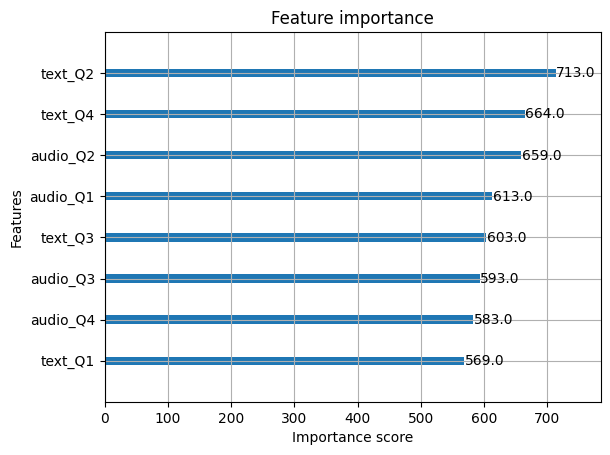

In [ ]:
feature_names = [
    "audio_Q1", "audio_Q2", "audio_Q3", "audio_Q4",
    "text_Q1", "text_Q2", "text_Q3", "text_Q4"
]

from xgboost import plot_importance
import matplotlib.pyplot as plt

xgb_model.get_booster().feature_names = feature_names

plot_importance(xgb_model, max_num_features=8)
plt.show()



In [ ]:
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

# ============================================================
# 1. Crear carpeta de salida para reportes
# ============================================================
fusion_xgb_dir = paths["REPORTS"] / "fusion_model_xgboost"
fusion_xgb_dir.mkdir(parents=True, exist_ok=True)

print("📁 Guardando resultados XGBoost en:", fusion_xgb_dir)

# ============================================================
# 2. Predicciones del modelo XGBoost
# ============================================================
print("\n🔮 Generando predicciones con XGBoost...")

probs_xgb = xgb_model.predict_proba(X_test)
y_pred_xgb = np.argmax(probs_xgb, axis=1)

print("✔ Predicciones listas.")


# ============================================================
# 3. Classification Report
# ============================================================
quadrant_names = ["Q1_Happy", "Q2_Angry", "Q3_Sad", "Q4_Relaxed"]

report_xgb = classification_report(
    y_test,
    y_pred_xgb,
    target_names=quadrant_names,
    digits=4
)

print("\n📊 CLASSIFICATION REPORT — XGBoost")
print(report_xgb)

# Guardar .txt
report_path = fusion_xgb_dir / "classification_report_xgboost.txt"
with open(report_path, "w") as f:
    f.write("Classification Report — XGBoost\n\n")
    f.write(report_xgb)

print(f"✔ Reporte guardado en: {report_path}")


# ============================================================
# 4. Matriz de Confusión
# ============================================================
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Guardar matriz en CSV
cm_csv_path = fusion_xgb_dir / "confusion_matrix_xgboost.csv"
np.savetxt(cm_csv_path, cm_xgb, fmt="%d", delimiter=",")

print(f"✔ Matriz de confusión guardada en: {cm_csv_path}")

# Plot PNG
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=quadrant_names,
    yticklabels=quadrant_names
)
plt.title("Matriz de Confusión — XGBoost Fusion Model")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Verdadera")

png_path = fusion_xgb_dir / "confusion_matrix_xgboost.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"✔ Imagen PNG guardada en: {png_path}")


📁 Guardando resultados XGBoost en: /content/drive/MyDrive/Proyecto Final MIR/reports/fusion_model_xgboost

🔮 Generando predicciones con XGBoost...
✔ Predicciones listas.

📊 CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

    Q1_Happy     0.7012    0.7718    0.7348       298
    Q2_Angry     0.7260    0.6823    0.7034       299
      Q3_Sad     0.8083    0.8490    0.8282       298
  Q4_Relaxed     0.7021    0.4459    0.5455        74

    accuracy                         0.7430       969
   macro avg     0.7344    0.6873    0.7030       969
weighted avg     0.7419    0.7430    0.7394       969

✔ Reporte guardado en: /content/drive/MyDrive/Proyecto Final MIR/reports/fusion_model_xgboost/classification_report_xgboost.txt
✔ Matriz de confusión guardada en: /content/drive/MyDrive/Proyecto Final MIR/reports/fusion_model_xgboost/confusion_matrix_xgboost.csv
✔ Imagen PNG guardada en: /content/drive/MyDrive/Proyecto Final MIR/reports/fusion_model_xgboost/

🔎 ACCURACY
Lineal Accuracy: 0.7327
XGBoost Accuracy:   0.7430

📊 Classification Report — Lineal
              precision    recall  f1-score   support

    Q1_Happy     0.6911    0.7282    0.7092       298
    Q2_Angry     0.7055    0.6890    0.6971       299
      Q3_Sad     0.7887    0.8893    0.8360       298
  Q4_Relaxed     0.8148    0.2973    0.4356        74

    accuracy                         0.7327       969
   macro avg     0.7500    0.6509    0.6695       969
weighted avg     0.7350    0.7327    0.7236       969


📊 Classification Report — XGBoost
              precision    recall  f1-score   support

    Q1_Happy     0.7012    0.7718    0.7348       298
    Q2_Angry     0.7260    0.6823    0.7034       299
      Q3_Sad     0.8083    0.8490    0.8282       298
  Q4_Relaxed     0.7021    0.4459    0.5455        74

    accuracy                         0.7430       969
   macro avg     0.7344    0.6873    0.7030       969
weighted avg     0.7419    0.7430    0.7394       969


,Clase,ModeloLineal_Precision,LinealNet_Recall,LinealNet_F1,XGB_Precision,XGB_Recall,XGB_F1
0,Q1_Happy,0.691083,0.728188,0.709150,0.701220,0.771812,0.734824
1,Q2_Angry,0.705479,0.688963,0.697124,0.725979,0.682274,0.703448
2,Q3_Sad,0.788690,0.889262,0.835962,0.808307,0.848993,0.828151
3,Q4_Relaxed,0.814815,0.297297,0.435644,0.702128,0.445946,0.545455


✔ Comparación guardada en: /content/drive/MyDrive/Proyecto Final MIR/reports/fusion_model_xgboost/comparison_lineal_xgboost.csv


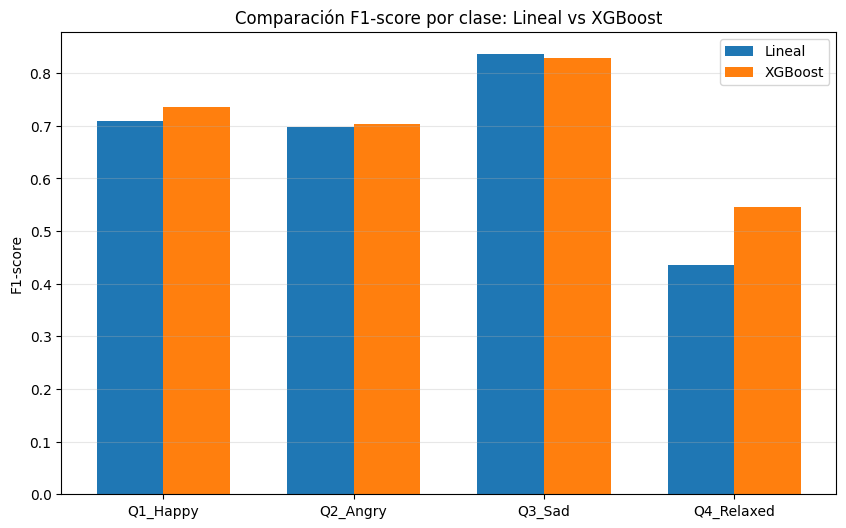

✔ Gráfico de comparación guardado en: /content/drive/MyDrive/Proyecto Final MIR/reports/fusion_model_xgboost


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Accuracy general de ambos modelos
# ============================================================

acc_fusion = accuracy_score(y_test, y_pred_test)
acc_xgb    = accuracy_score(y_test, y_pred_xgb)

print("🔎 ACCURACY")
print(f"Lineal Accuracy: {acc_fusion:.4f}")
print(f"XGBoost Accuracy:   {acc_xgb:.4f}")


# ============================================================
# 2. Classification Report detallado (para impresión en pantalla)
# ============================================================

print("\n📊 Classification Report — Lineal")
print(classification_report(y_test, y_pred_test, target_names=quadrant_names, digits=4))

print("\n📊 Classification Report — XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=quadrant_names, digits=4))


# ============================================================
# 3. Resumen Tabular Comparativo
# ============================================================

prec_f, rec_f, f1_f, _ = precision_recall_fscore_support(y_test, y_pred_test, labels=[0,1,2,3])
prec_x, rec_x, f1_x, _ = precision_recall_fscore_support(y_test, y_pred_xgb, labels=[0,1,2,3])

comparison_df = pd.DataFrame({
    "Clase": quadrant_names,
    "ModeloLineal_Precision": prec_f,
    "LinealNet_Recall": rec_f,
    "LinealNet_F1": f1_f,
    "XGB_Precision": prec_x,
    "XGB_Recall": rec_x,
    "XGB_F1": f1_x,
})

display(comparison_df)

# Guardar como CSV
comparison_path = fusion_xgb_dir / "comparison_lineal_xgboost.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"✔ Comparación guardada en: {comparison_path}")


# ============================================================
# 4. Gráfico Comparativo de F1-score por Clase
# ============================================================

plt.figure(figsize=(10,6))
x = np.arange(len(quadrant_names))
width = 0.35

plt.bar(x - width/2, f1_f, width, label="Lineal")
plt.bar(x + width/2, f1_x, width, label="XGBoost")

plt.xticks(x, quadrant_names)
plt.ylabel("F1-score")
plt.title("Comparación F1-score por clase: Lineal vs XGBoost")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.savefig(fusion_xgb_dir / "f1_comparison_lineal_xgboost.png", dpi=300)
plt.show()

print(f"✔ Gráfico de comparación guardado en: {fusion_xgb_dir}")
